In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import glob
import os

folder_path = '/content/drive/MyDrive/CIC-IDS2017'
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

print(f"found {len(all_files)} files. Merging now... ")
# this reads every csv and stacks them on top of each other
df_list = [pd.read_csv(file) for file in all_files]
df = pd.concat(df_list, ignore_index=True)

print(f"merge complete.. Dataset shape: {df.shape}")

found 8 files. Merging now... 
merge complete.. Dataset shape: (2830743, 79)


In [3]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
df.shape

(2830743, 79)

In [5]:
df.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [7]:
df.columns = df.columns.str.strip()

In [8]:
# selecting only the numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# checking for infinity and counting them per column
inf_counts = np.isinf(numeric_df).sum()

# printing only the columns that actually have inf values
columns_with_inf = inf_counts[inf_counts > 0]
print(columns_with_inf)
print(f'\n Total columns containing inf: {len(columns_with_inf)}')

Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64

 Total columns containing inf: 2


In [9]:
# some netwrok flow math resulted in infinity or Nan
# convert infinity to NaN, and then drop all rows containing NaN.
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f'Final cleaned dataset shape {df.shape}')

Final cleaned dataset shape (2827876, 79)


In [10]:
print(df.isnull().sum())

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64


In [11]:
df['Label'].unique()

array(['BENIGN', 'DDoS', 'PortScan', 'Bot', 'Infiltration',
       'Web Attack � Brute Force', 'Web Attack � XSS',
       'Web Attack � Sql Injection', 'FTP-Patator', 'SSH-Patator',
       'DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye',
       'Heartbleed'], dtype=object)

In [12]:
# Replacing the  �  character with a hyphen
df['Label'] = df['Label'].str.replace(' � ', '-', regex=False)

print(df['Label'].unique())

['BENIGN' 'DDoS' 'PortScan' 'Bot' 'Infiltration' 'Web Attack-Brute Force'
 'Web Attack-XSS' 'Web Attack-Sql Injection' 'FTP-Patator' 'SSH-Patator'
 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye'
 'Heartbleed']


In [13]:
df['Label'].value_counts()

,count
Label,
BENIGN,2271320
DoS Hulk,230124
PortScan,158804
DDoS,128025
DoS GoldenEye,10293
FTP-Patator,7935
SSH-Patator,5897
DoS slowloris,5796
DoS Slowhttptest,5499


In [14]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,...,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06
mean,8.061534e+03,1.480065e+07,9.368972e+00,1.040396e+01,5.498522e+02,1.617903e+04,2.078044e+02,1.872929e+01,5.825628e+01,6.897811e+01,...,5.423519e+00,-2.744494e+03,8.163400e+04,4.117582e+04,1.533378e+05,5.835492e+04,8.324468e+06,5.043548e+05,8.704568e+06,7.928061e+06
std,1.827432e+04,3.366750e+07,7.500527e+02,9.978937e+02,9.998639e+03,2.264235e+06,7.175183e+02,6.035533e+01,1.861733e+02,2.813212e+02,...,6.367482e+02,1.085539e+06,6.489234e+05,3.935787e+05,1.026333e+06,5.773818e+05,2.364057e+07,4.605289e+06,2.437766e+07,2.337390e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,2.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.133800e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.239368e+06,5.000000e+00,4.000000e+00,1.880000e+02,4.840000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


/tmp/ipykernel_4698/1294806043.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_labels.values, y=top_labels.index, palette='viridis')


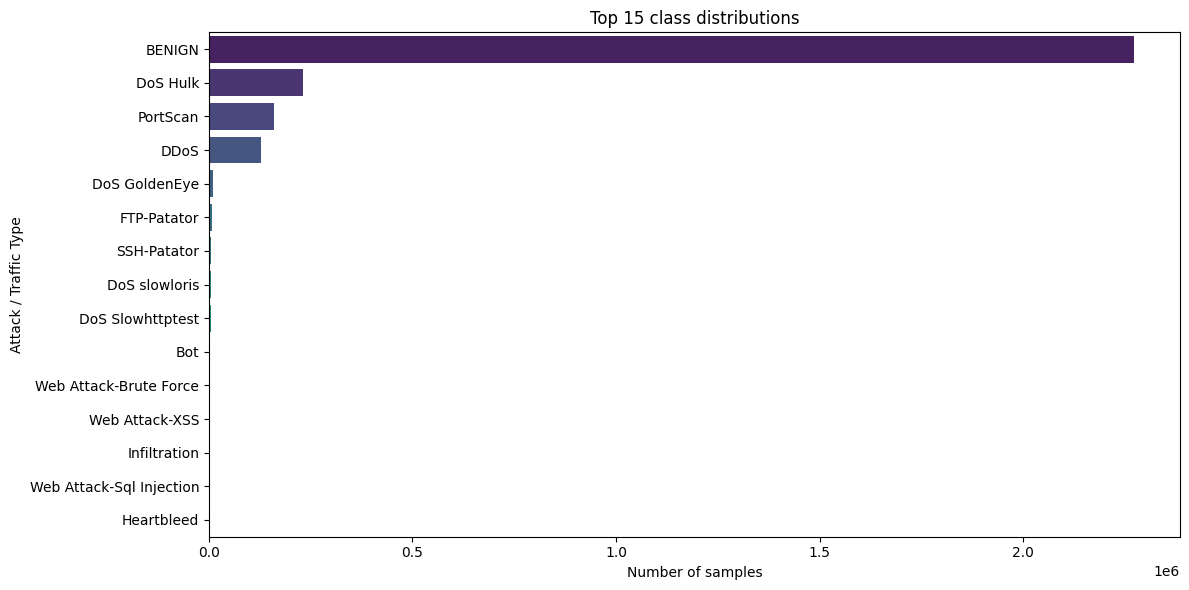

In [15]:
# Label Distribution Analysis
plt.figure(figsize=(12,6))
top_labels=df['Label'].value_counts()

sns.barplot(x=top_labels.values, y=top_labels.index, palette='viridis')
plt.title('Top 15 class distributions')
plt.xlabel('Number of samples')
plt.ylabel('Attack / Traffic Type')
plt.tight_layout()
plt.show()

In [16]:
# correlation matrix (finding redundant features)
df_sample = df.sample(n=100000, random_state=42)

# # droping the categorical column 'Label' before calculating correlation
numeric_df = df_sample.drop(columns=['Label'], errors='ignore')



In [17]:
# Identifying zero-variance features
# if a feature has a std of 0, it holds the same value for every single packet
variances = numeric_df.std()
zero_variance_cols = variances[variances == 0].index.tolist()

if len(zero_variance_cols) > 0:
  print('These features never change', zero_variance_cols)

These features never change ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [18]:
# dropping zero variance columns before correlation to avoid math errors
numeric_df.drop(columns=zero_variance_cols, inplace=True, errors='ignore')
print('numeric_df shape', numeric_df.shape)

numeric_df shape (100000, 70)


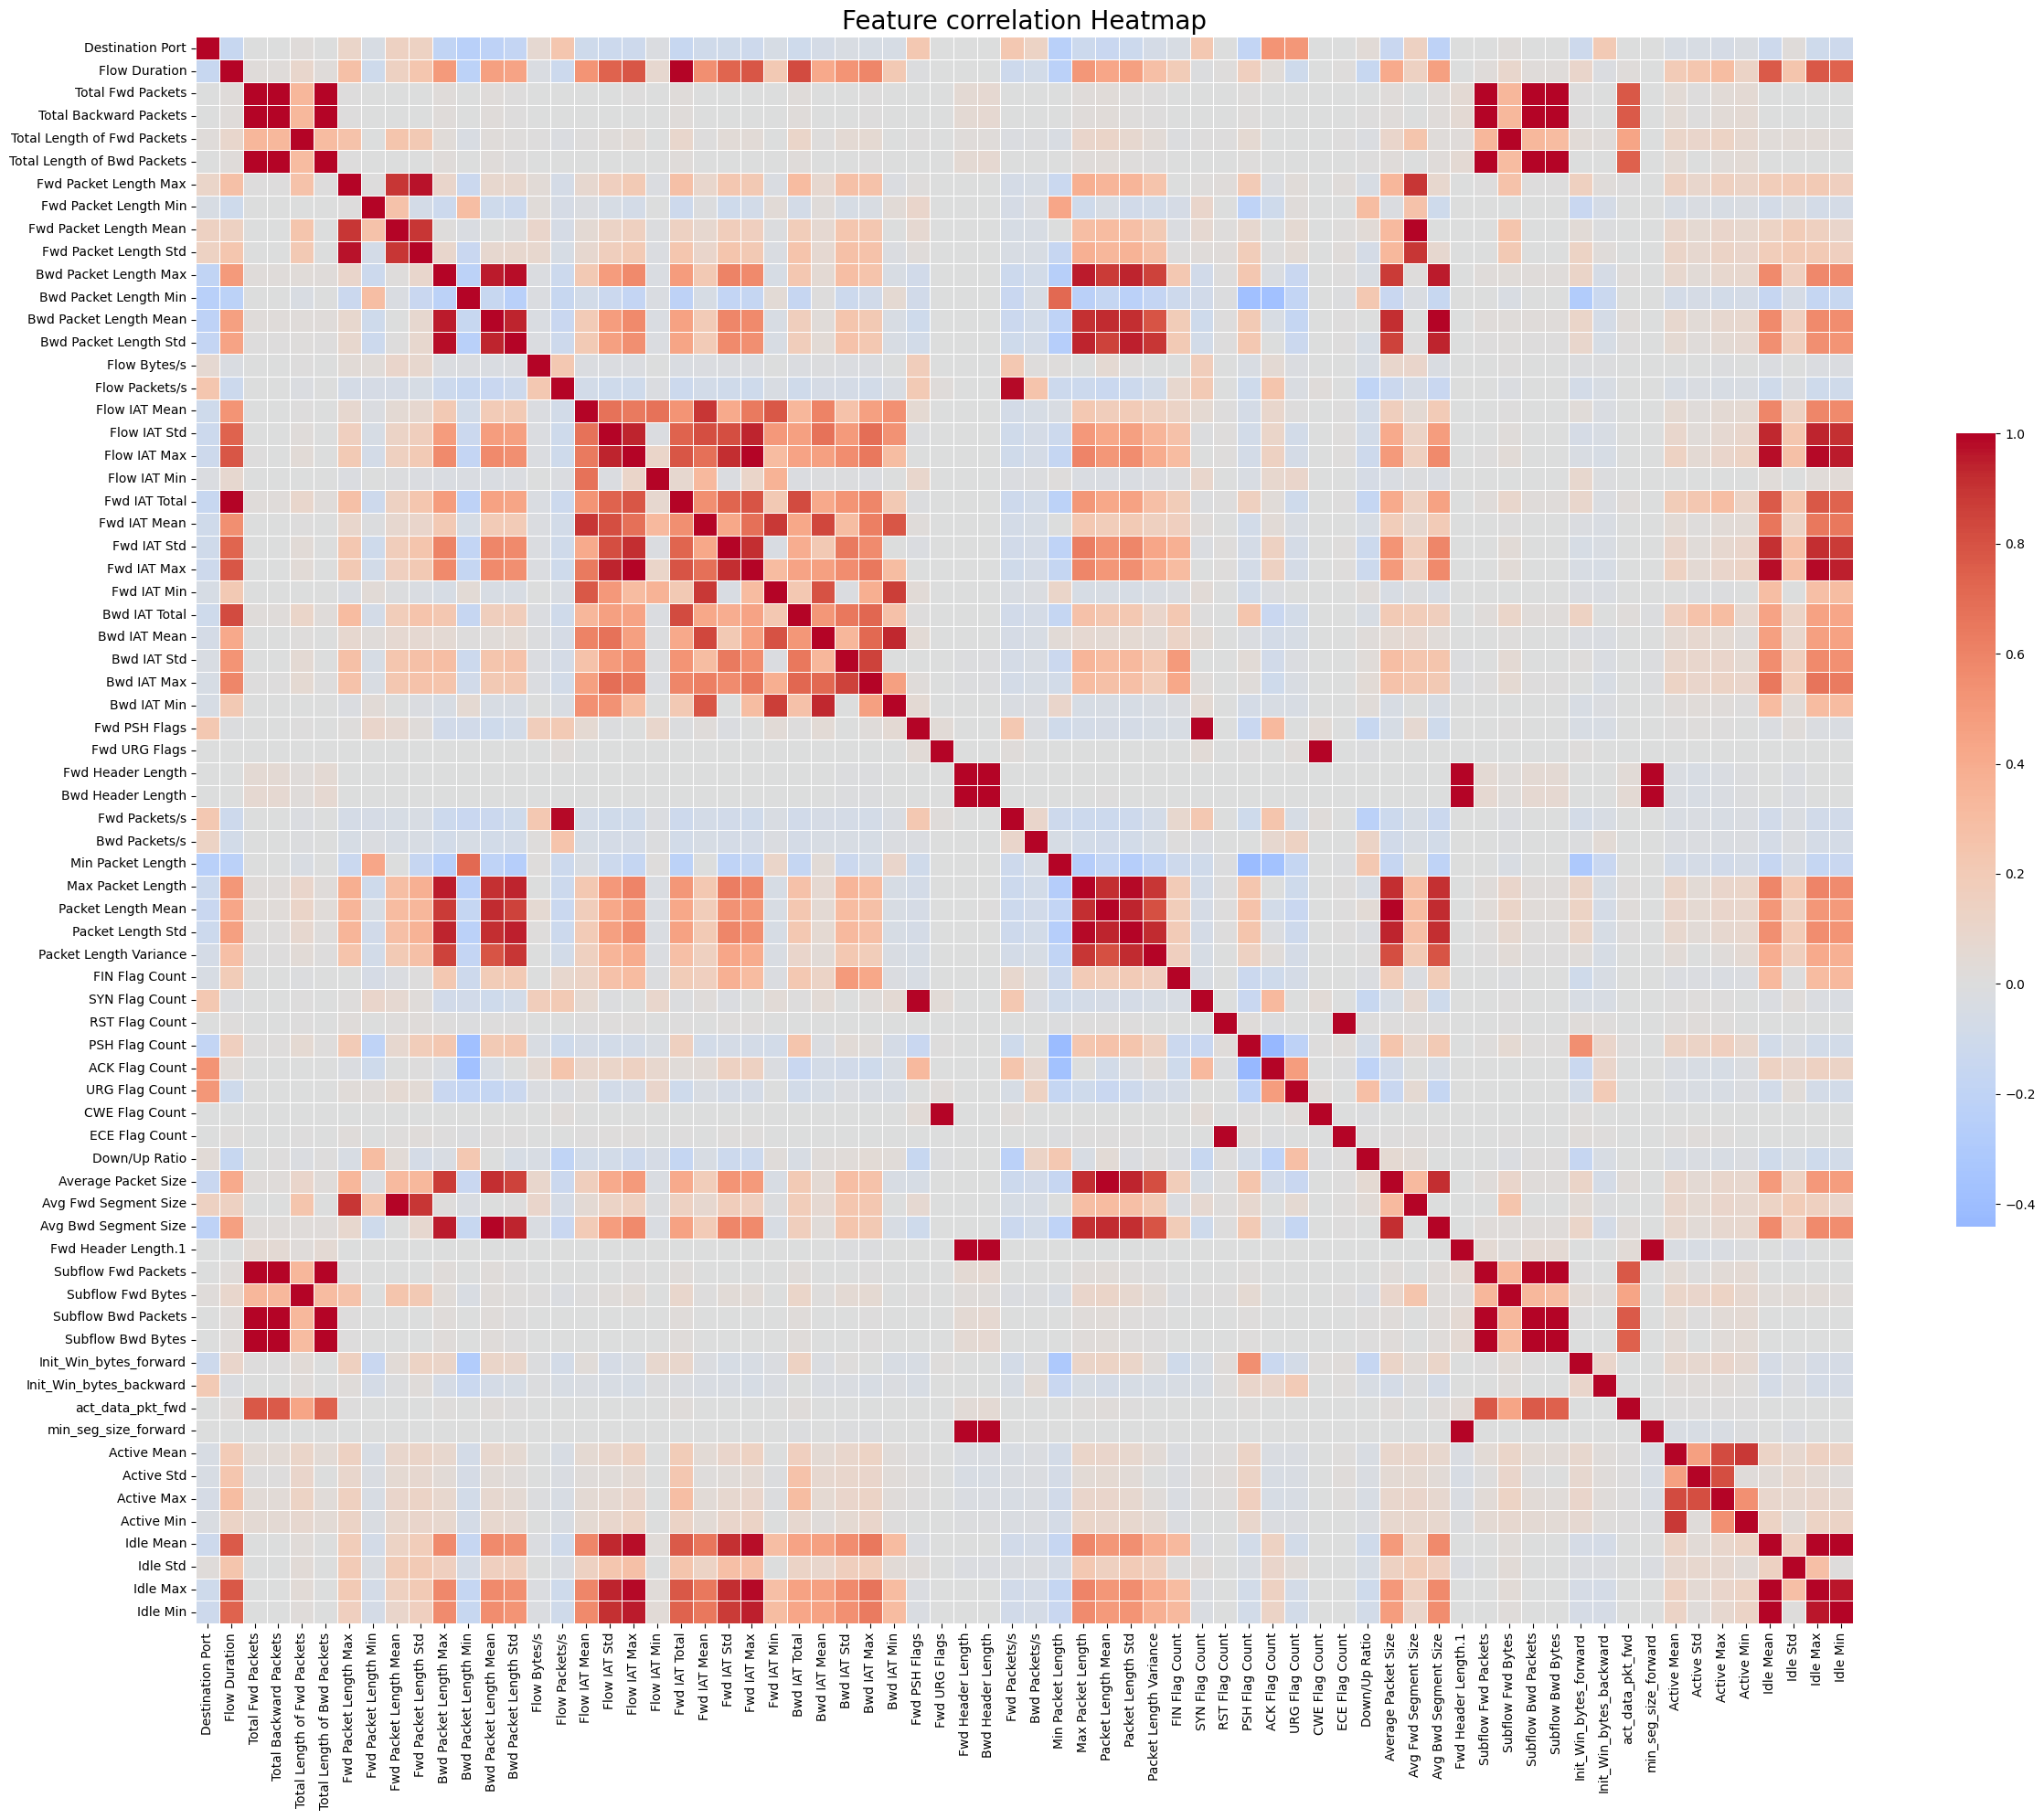

In [19]:
corr_matrix = numeric_df.corr()

plt.figure(figsize=(25,20))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidths=.5, cbar_kws={'shrink': .5})
plt.title('Feature correlation Heatmap', fontsize=20)
plt.tight_layout()
plt.show()

In [20]:
# Identifying the highly correlated features to drop
# if two features have a correlation > 0.95, they are providing the exact same information.
threshold=0.95
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column].abs() > threshold)]

print(f'{len(to_drop)} features are highly correlated')
print(to_drop)

26 features are highly correlated
['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Bwd Header Length', 'Fwd Packets/s', 'Max Packet Length', 'Packet Length Std', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'min_seg_size_forward', 'Idle Mean', 'Idle Max', 'Idle Min']


In [21]:
master_drop_list = zero_variance_cols + to_drop
print(master_drop_list)

['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Bwd Header Length', 'Fwd Packets/s', 'Max Packet Length', 'Packet Length Std', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'min_seg_size_forward', 'Idle Mean', 'Idle Max', 'Idle Min']


In [22]:


df_clean = df.drop(columns=master_drop_list, errors='ignore')


print('original df shape', df.shape)
print('cleaned df shape', df_clean.shape)



original df shape (2827876, 79)
cleaned df shape (2827876, 45)


In [24]:
# creating binary labels
df_clean['is_attack'] = df_clean['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# splitting benign and attack traffic data
# benign_data = df_clean[df_clean['is_attack'] == 0]
# attack_data = df_clean[df_clean['is_attack'] == 1]

In [25]:
X = df_clean.drop(columns=['Label', 'is_attack'])
y = df_clean['is_attack']

In [26]:
#80/20 split
# stratify=y ensures that both the train and test have the exact same ratio of attacks
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f'Training data: {X_train.shape[0]} rows')
print(f'Testing data: {X_test.shape[0]} rows')

Training data: 2262300 rows
Testing data: 565576 rows


In [27]:
# Scaling the data
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
print(f'Training data shape (scaled) {X_train_scaled.shape}')
print(f'Testing data shape (scaled) {X_test_scaled.shape}')

Training data shape (scaled) (2262300, 44)
Testing data shape (scaled) (565576, 44)


In [29]:
print('\n Training the XGBoost Model')

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)


 Training the XGBoost Model


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)


 Final Evaluation
Classification Report

              precision    recall  f1-score   support

  Benign (0)     0.9995    0.9992    0.9994    454265
  Attack (1)     0.9969    0.9980    0.9975    111311

    accuracy                         0.9990    565576
   macro avg     0.9982    0.9986    0.9984    565576
weighted avg     0.9990    0.9990    0.9990    565576



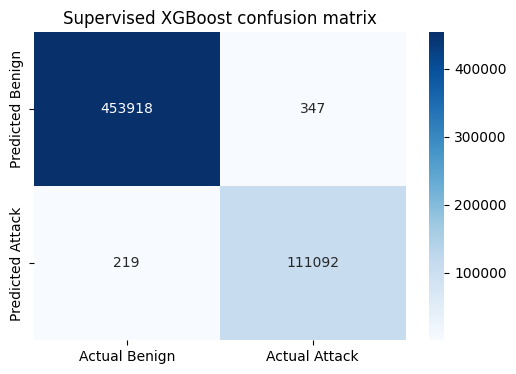

In [32]:
print('\n Final Evaluation')

# asking the model to predict the test set
predictions = xgb_model.predict(X_test_scaled)

print('Classification Report\n')

print(classification_report(y_test, predictions, target_names=['Benign (0)', 'Attack (1)'], digits=4))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues', xticklabels=['Actual Benign', 'Actual Attack'], yticklabels=['Predicted Benign', 'Predicted Attack'])

plt.title('Supervised XGBoost confusion matrix')
plt.show()


In [ ]:
# import joblib
# joblib.dump(iso_forest, 'isolation_model.pkl')
# joblib.dump(scaler, 'scaler.pkl')